# Day 21

## Regularisation

As a regression model becomes more flexible, it can start fitting the noise in the training data rather than the underlying relationship.

A higher degree polynomial is a good example. It can achieve a very small training error while developing large oscillations between the observed points. If we repeated the experiment with slightly different noisy data, the fitted curve could change substantially, this is what high variance means in relation to overfitting

We can see this directly with polynomial regression here

WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.


WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


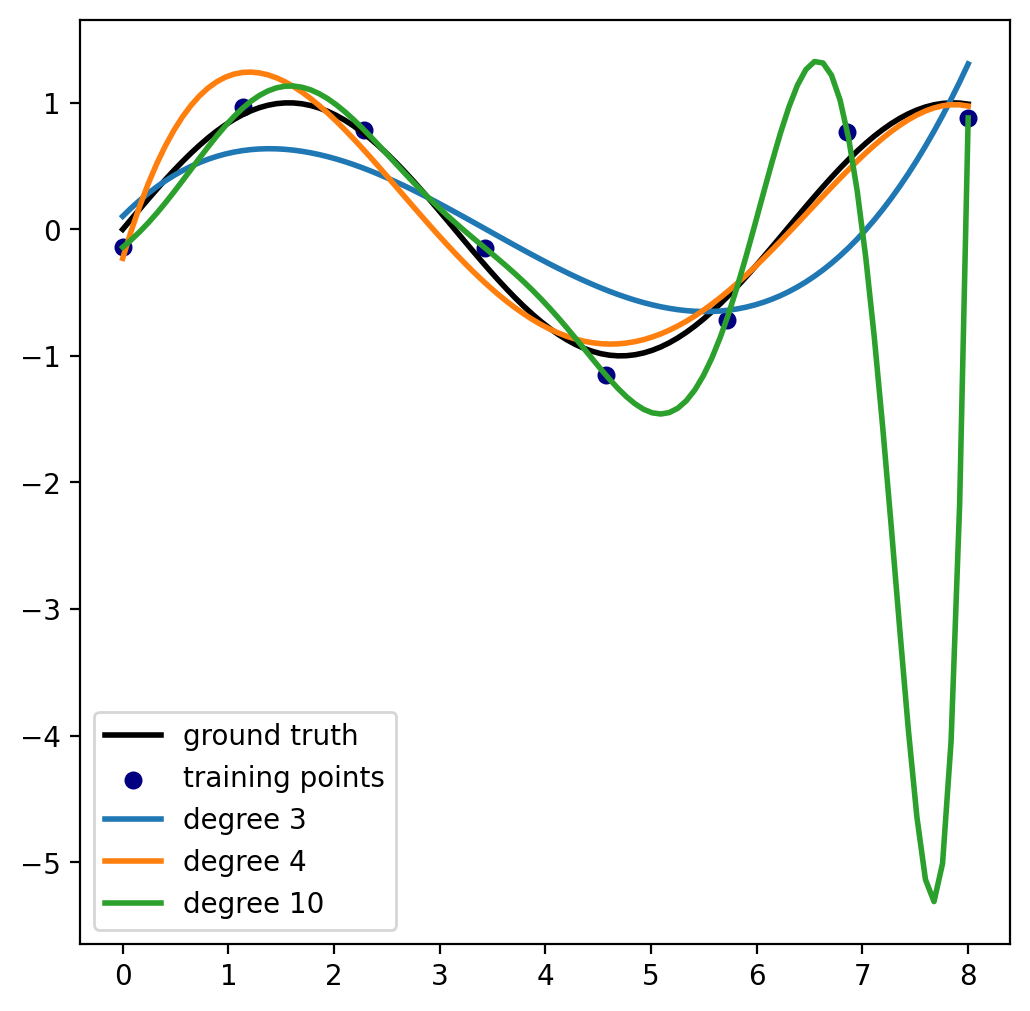

In [2]:
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from astroML.linear_model import PolynomialRegression

degrees = [3,4,10]

def f(x):
    """ function to approximate by polynomial interpolation """
    return np.sin(x)

# generate points used to plot
x_plot = np.linspace(0, 8, 100)

# generate points and keep a subset of them
x = np.linspace(0, 8, 8)
y = f(x) + 0.5 * (np.random.random(len(x)) - 0.5)

# create matrix versions of these arrays
X = x[:, None]
X_plot = x_plot[:, None]

colors = ['C0', 'C1', 'C2']
lw = 2
plt.figure(figsize=(6,6))
plt.plot(x_plot, f(x_plot), 
         color='black', 
         linewidth=lw, label="ground truth")
plt.scatter(x, y, color='navy', s=30, 
            marker='o', label="training points")

for count, degree in enumerate(degrees):
    poly = PolynomialRegression(degree)
    poly.fit(X,y)
    y_plot = poly.predict(X_plot)

    plt.plot(x_plot, y_plot, color=colors[count], 
             linewidth=lw, label="degree %d" % degree)

plt.legend(loc='lower left')

plt.show();

The 10 degree model has enough freedom within it's parameters to go through each of the 8 points. However, this has a high variance as can be seen between the 7th and 8th marker.

For ordinary regression, the basic idea is to minimise the squared residuals:

$$
\text{loss}=\sum_i (y_i-\hat y_i)^2
$$

Regularisation adds a second requirement:

$$
\text{total cost}
=
\text{fit error}
+
\lambda\,\text{model penalty}
$$

So the model will have 2 goals:

- fit the observations well
- avoid becoming unnecessarily extreme

The parameter $\lambda$ controls how strongly we want to prioritise the 2nd goal.

### Ridge regression

Ridge regression uses the squared size of the fitted coefficients as the penalty:

$$
J(\beta)
=
\sum_{i=1}^{n}(y_i-\hat y_i)^2
+
\lambda\sum_{j=1}^{p}\theta_j^2
$$


The first term pulls the model towards the data. The second discourages the fit from using very large coefficients simply to reduce the training error a little more.

This is especially useful when a flexible model has many correlated terms. Large positive and negative coefficients can partially cancel at the training points while producing a very unstable curve between them.

The intercept is normally not included in the Ridge penalty.

$\lambda$ controls the trade off between bias and variance:

- $\lambda=0$: ordinary least squares
- small $\lambda$: weak regularisation, so the model remains flexible
- large $\lambda$: strong regularisation, so the coefficients are pushed more strongly towards zero

Too little regularisation can leave us overfitting. Too much can make the model too simple and cause underfitting. We therefore treat $\lambda$ as a **hyperparameter** and choose it using cross validation.

Ridge regression can also be viewed in a similar, constrained form, where instead of adding a penalty, we restrict the total squared size of the coefficients:

$$\theta^T \theta \equiv \sum_i \theta_i^2 < s$$

Here, $s$ sets how large the coefficients are collectively allowed to become. Where a smaller s is stronger regularisation

The same idea can be written in the full matrix notation from linear regression.

The weighted leastsquares term is

$$
(Y-M\theta)^T C^{-1}(Y-M\theta)
$$

where:

- $Y$ contains the observed values
- $M\theta$ contains the model predictions
- $Y-M\theta$ is therefore the vector of residuals
- $C$ is the covariance matrix of the observations

For independent measurements, this is the matrix version of

$$
\sum_i\frac{(y_i-\hat y_i)^2}{\sigma_i^2}
$$

Ridge regression adds the coefficient penalty:

$$
J(\theta)
=
(Y-M\theta)^T C^{-1}(Y-M\theta)
+
\lambda\theta^T\theta
$$

with

$$
\theta^T\theta=\sum_j\theta_j^2
$$

The solution becomes

$$
\hat\theta_{\rm Ridge}
=
(M^T C^{-1}M+\lambda I)^{-1}M^T C^{-1}Y
$$

Compare this with ordinary weighted least squares:

$$
\hat\theta_{\rm OLS}
=
(M^T C^{-1}M)^{-1}M^T C^{-1}Y
$$

The important new piece is simply

$$
+\lambda I
$$

As well as shrinking the coefficients, this can make the matrix inversion more stable as the denominator will be at least $\lambda$. Without ridge, this would be inverting near 0 eigenvalues, which requires dividing by a tiny number and can cause rounding errors to blow up.

### Bayesian view

This can be connected to Bayes

For Gaussian measurement uncertainties, the regression likelihood has the form

$$
p(Y\mid\theta)
\propto
\exp\left[
-\frac12
(Y-M\theta)^T C^{-1}(Y-M\theta)
\right]
$$

so maximising the likelihood is equivalent to minimising the weighted squared residuals.

Now place a Gaussian prior centred on zero on the model coefficients:

$$
p(\theta)
\propto
\exp\left(
-\frac{\lambda}{2}\theta^T\theta
\right)
$$

Using Bayes,

$$
p(\theta\mid Y)
\propto
p(Y\mid\theta)p(\theta)
$$

and multiplying the two exponentials gives

$$
p(\theta\mid Y)
\propto
\exp\left[
-\frac12
\left(
(Y-M\theta)^T C^{-1}(Y-M\theta)
+
\lambda\theta^T\theta
\right)
\right]
$$

The expression inside the brackets is exactly what we want from ridge

This means we can interpret it in to ways, with regularisation, we penalise very large coefficients, and with the bayesian approach a prior is used that says very large coefficients are less plausible


Finding the maximum of this posterior gives the Ridge solution as a MAP estimate

Regularisation allows for a little extra bias if it produces a much more stable model with lower variance on the test data. The strength of this  tradeoff is controlled by $\lambda$ and should be chosen using cross validation as mentioned before.

In [3]:
from sklearn.linear_model import Ridge

X = np.random.random((100,10))
y = np.dot(X, np.random.random(10))
model = Ridge(alpha=0.05) # alpha here is lambda in the book
model.fit(X,y)
y_pred = model.predict(X)

We will use supernova data.

The following example compares Gaussian Basis Regression with and without the constraints from Ridge Regression. It uses 100 evenly spaced Gauassians, which we can see strongly overfits the problem and has very large coefficient values, until a constraint is imposed.

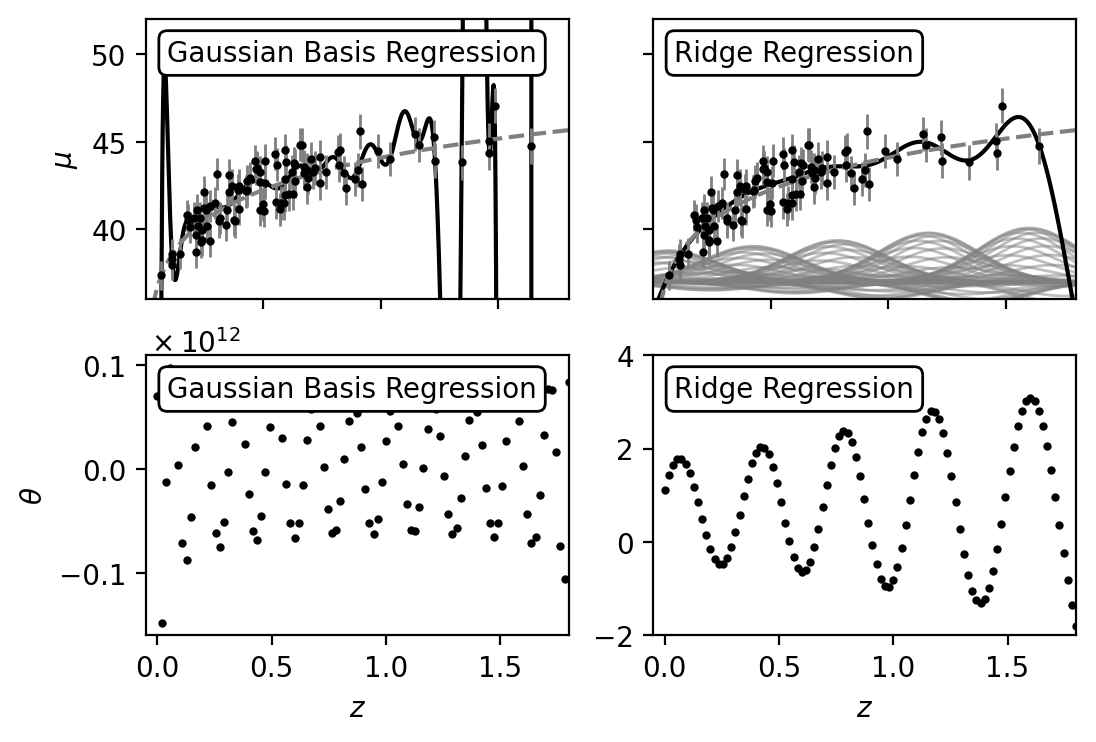

In [5]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy.stats import lognorm
from sklearn.linear_model import LinearRegression, Ridge
from astroML.datasets import generate_mu_z

#----------------------------------------------------------------------
# generate data
np.random.seed(0)
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=0)

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.30, Ode0=0.70, Tcmb0=0)
z = np.linspace(0.01, 2, 1000)
mu = cosmo.distmod(z)

#------------------------------------------------------------
# Manually convert data to a gaussian basis
#  note that we're ignoring errors here, for the sake of example.
def gaussian_basis(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

centers = np.linspace(0, 1.8, 100)
widths = 0.2
X = gaussian_basis(z_sample[:, None], 
                   centers, widths)

#------------------------------------------------------------
# Set up the figure to plot the results
fig = plt.figure(figsize=(6, 4))

classifier = [LinearRegression, Ridge]
kwargs = [dict(), dict(alpha=0.005)]
labels = ['Gaussian Basis Regression', 'Ridge Regression']

for i in range(2):
    clf = classifier[i](fit_intercept=True, **kwargs[i])
    clf.fit(X, mu_sample)
    w = clf.coef_
    fit = clf.predict(gaussian_basis(z[:, None], 
                                     centers, widths))

    # plot fit
    ax = fig.add_subplot(221 + i)
    ax.xaxis.set_major_formatter(plt.NullFormatter())

    # plot curves for regularized fits
    if i == 0:
        ax.set_ylabel('$\mu$')
    else:
        ax.yaxis.set_major_formatter(plt.NullFormatter())
        curves = 37 + w * gaussian_basis(z[:, np.newaxis], 
                                         centers, widths)
        curves = curves[:, abs(w) > 0.01]
        ax.plot(z, curves,
                c='gray', lw=1, alpha=0.5)

    ax.plot(z, fit, '-k')
    ax.plot(z, mu, '--', c='gray')
    ax.errorbar(z_sample, mu_sample, dmu, 
                fmt='.k', ecolor='gray', lw=1, ms=4)
    ax.set_xlim(0.001, 1.8)
    ax.set_ylim(36, 52)
    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', 
                      ec='k', fc='w'),
            transform=ax.transAxes)

    # plot weights
    ax = plt.subplot(223 + i)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_xlabel('$z$')
    if i == 0:
        ax.set_ylabel(r'$\theta$')
        w *= 1E-12
        ax.text(0, 1.01, r'$\rm \times 10^{12}$',
                transform=ax.transAxes)
    ax.scatter(centers, w, s=9, lw=0, c='k')

    ax.set_xlim(-0.05, 1.8)

    if i == 1:
        ax.set_ylim(-2, 4)
    elif i == 2:
        ax.set_ylim(-0.5, 2)

    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', 
                      ec='k', fc='w'),
            transform=ax.transAxes)

plt.show()

### Least Absolute Shrinkage and Selection Regularisation

This is an alternative to Ridge regression that introduces the following constraint:

$$(Y - M \theta)^T(Y- M \theta) + \lambda \sum_i|\theta_i|.$$

This is equivalent to what we mentioned before to least squares minimisation with the following restriction:

$$\sum_i|\theta_i| < s,$$

before within Ridge regression, we could have some of our constraints go asymptotically to 0 but not entirely 0. However within Lasso regression we can make regression coefficients go to 0. This effectively removes the irrelevant features from the model.


Just an example use of the code:



In [6]:
from sklearn.linear_model import Lasso

XX = np.random.random((100,10))
yy = np.dot(XX, np.random.random(10))
model = Lasso(alpha = 0.05)
model.fit(XX,yy)
y_pred = model.predict(XX)

We can also think of the constraint term as 

$$\lambda \sum_{i=1} |\theta_i|^q,$$

Meaning that Ridge regression corresponds to $q=2$, whereas LASSO regression corresponds to $q=1$. This means they're basically the same thing; Bayesian estimates with different priors. Hastie et al. shows what contours of what constant constrain terms look like for different $q$

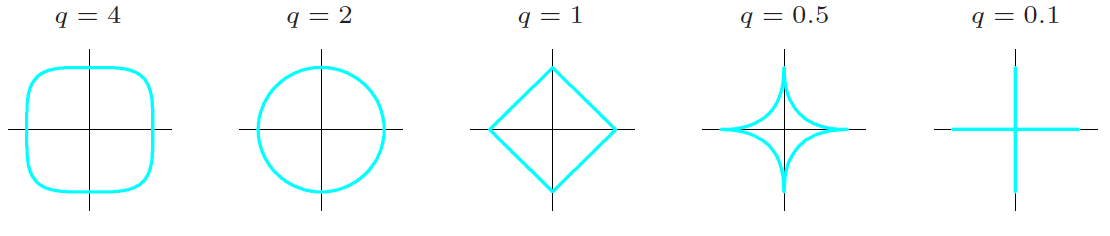

And a slightly more in depth discussion on this:

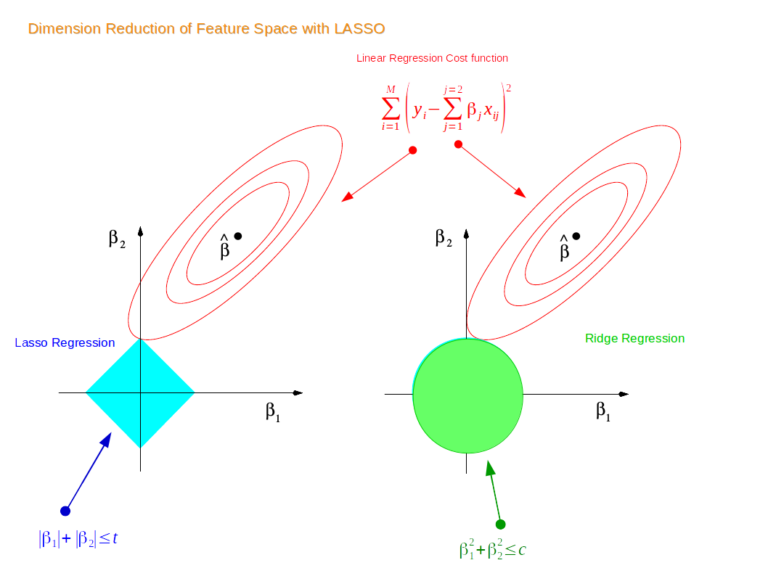

[Here](https://towardsdatascience.com/ridge-and-lasso-regression-a-complete-guide-with-python-scikit-learn-e20e34bcbf0b/) the red ellipses are the equal error contours. Smaller ellipses show a better fit, with the black dot, $\hat{\beta}$ representing the ordinary least squares solution. 

1. Ridge regression constrains the coefficients by $\beta_1^2+\beta_2^2\leq s$. Hence, the allowed region is a circle. The regularised solution is where the smallest possible loss ellipse first touches this circle. Because the boundary is smooth, the coefficients are generally shrunk towards zero but not set exactly to zero.

2. LASSO regression uses the constraint $|\beta_1|+|\beta_2|\leq s$. Hence, the allowed region is a diamond. Its corners lie on the axes, so the loss ellipse can touch at a corner, giving $\beta_j=0$. This is why LASSO can perform feature selection.

A drawback of LASSO is that it doesn't have a closed form analytical regression like Ridge, instead it has to be solved numerically.

### Elastic Net 

This is the combined union of Lasso and Ridge regression where we have the following

$$(Y - M \theta)^T(Y- M \theta) + \lambda_1 \sum_i|\theta_i| + \lambda_2 \sum_i\theta_i^2  $$
We use cross validation on different combinations of $\lambda_1$ and $\lambda_2$ to find the best values.

We can see that Elastic Net regression can reduce down into, Ridge, Lasso or sum of the squared residuals.

However, the hybrid form, Elastic Net regression, is good at dealing with situations when there are correlations between parameters.

### Gaussian Process Regression

This is a powerful class of regression algorithms. Unlike standard regression methods that fit coefficients to a fixed equation, Gaussian Process Regression (GPR) defines a distribution over possible functions.

A Gaussian process is a collection of random variables indexed by the input $x$, where any finite subset of function values $\{f(x_1), f(x_2), \dots, f(x_n)\}$ has a joint Gaussian distribution:

$$f(x) \sim \mathcal{GP}\left(m(x), k(x,x')\right)$$

A Gaussian process is completely specified by two functions:
- Mean function $m(x)$: describes the expected function value before seeing any data
- Covariance function $k(x,x')$: describes how function values at different inputs are correlated


##### The Covariance Function (Kernel)

For a one-dimensional squared-exponential covariance function:

$$\mathrm{Cov}(x_1,x_2;h)=\exp\left[-\frac{(x_1-x_2)^2}{2h^2}\right]$$

where $h$ is the length scale (bandwidth):

- **Close inputs ($x_1 \approx x_2$):** $\mathrm{Cov} \approx 1 \implies f(x_1)$ and $f(x_2)$ are strongly correlated.
- **Distant inputs ($|x_1-x_2| \gg h$):** $\mathrm{Cov} \approx 0 \implies$ function values vary approximately independently.
- **Small $h$:** allows rapidly varying, wiggly functions.
- **Large $h$:** enforces smooth, slowly varying functions.

The covariance function sets the statistical properties of all possible curves before observing data.


##### How Does the Regression Process Work?

Gaussian Process Regression proceeds through five key steps:

**1. Prior Model**  
Assume the true relation is a continuous function $f(x)$ drawn from a Gaussian process prior.

**2. Observations**  
We collect measurements with observational uncertainties:
$$\{x_i, y_i, \sigma_i\}$$

**3. Conditioning via Block Covariance**  
We use the data to rule out incompatible functions. To make predictions at new query points $x_j^*$, we construct the joint covariance matrix:

$$
K =
\begin{pmatrix}
K_{11} & K_{12} \\
K_{12}^T & K_{22}
\end{pmatrix}
$$

where:
- $K_{11}$: covariance between observed training points $x_i$, with measurement errors $\sigma_i^2$ added to the diagonal ($K_{11} + \operatorname{diag}(\sigma_i^2)$).
- $K_{12}$: cross-covariance between observed training points $x_i$ and new query points $x_j^*$.
- $K_{22}$: covariance between new query points $x_j^*$.

**4. Posterior Distribution**  
Conditioning the joint Gaussian prior on the observations yields an analytic posterior Gaussian distribution at the new points:

$$p(f^* \mid \{x_i,y_i,\sigma_i\},x^*) = \mathcal{N}\left(\bar{\mu}, \Sigma\right)$$

The posterior mean and covariance are given directly by:

$$\bar{\mu} = K_{12}^T K_{11}^{-1} \mathbf{y}$$

$$\Sigma = K_{22} - K_{12}^T K_{11}^{-1} K_{12}$$

**5. Output Predictions with Error Bars**  
The final prediction at any location is a Gaussian distribution:

$$f^* \mid \text{data} \sim \mathcal{N}\left(\mu^*, \Sigma^*\right)$$

- $\mu^*$ is the best estimate (the mean of all surviving curves).
- $\Sigma^*$ provides the predictive uncertainty and correlations (giving natural error bars).


### Non linear Regression

We have mostly so far just looked at situations where the model depends linearly on the regression coefficients. 

Sometimes we can make our nonlinear data linear, for example if our values increase exponentially with x, we can take the log. But this has many complications so we look at non-linear regression. Where the model depends non-linearly on the regression parameters.

If we know the theoretical form of the model, we can use ***mcmc*** to sample the parameter space and find optical model parameters.

We could also use the Levenberg-Marquardt (LM) algorithm to optimise the likelihood estimation. (apparently this is everywhere so should have a look later!)

### We will come back to this

